# Homework 4: Model Evaluation and Comparison

BEE 4850/5850, Fall 2025

**Name**:

**ID**:

> **Due Date**
>
> Friday, 3/27/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice model evaluation and
using cross-validation and information criteria to distinguish between
models.

-   Problem 1 asks you to fit a model for cherry blossom bloom dates and
    use cross-validation to draw conclusions about generalizability.
-   Problem 2 asks you to compare several linear regression models for
    environmental influences on non-accidental death data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.Registry.update()
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()

  Activating project at `c:\Users\nicho\Documents\hw04-NickZajac56`
    Updating registry at `C:\Users\nicho\.julia\registries\General.toml`
     Project No packages added to or removed from `C:\Users\nicho\Documents\hw04-NickZajac56\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nicho\Documents\hw04-NickZajac56\Manifest.toml`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [3]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization package for model fitting
using Dates # API for date-time data structures
using Pkg
Pkg.add("GLM")
using GLM


    Updating registry at `C:\Users\nicho\.julia\registries\General.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\nicho\Documents\hw04-NickZajac56\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nicho\Documents\hw04-NickZajac56\Manifest.toml`


## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 15 points;

### Problem 1

Let’s examine the influence of global temperature change on the blooming
day of cherry blossoms in Kyoto. While these dates are discrete, we will
use a linear regression model relating the day to the global mean
temperature anomaly for March (the third non-year column in
`data/HadCRUT5.1Analysis_gl.txt`).

#### Problem 1.1

Load the data and fit this model. What does your fitted model suggest as
the influence of March temperature anomalies on the cherry blossom date?

#### Problem 1.2

Calculate the log-loss (negative log-probability) and mean-squared error
metrics for the fitted model on the in-sample data.

#### Problem 1.3

Conduct a 5-fold cross-validation for the model using both of these
metrics. How do they compare to the in-sample metrics?

#### Problem 1.4

What conclusions can you draw about the model’s generalizability?

In [4]:
#Load data files to only care about the global mean temperature anomaly for March

#read the data in

lines = readlines("data/HadCRUT5.1Analysis_gl.txt")

#Go through crut5 and skip over every other row to focus on global mean 
#temperature anomaly data and pull out data for March

crut5 = CSV.read(IOBuffer(join(lines[1:2:end], "\n")), 
    DataFrame; delim = ' ', ignorerepeated = true, header = false)

#gives us an nx2 dataframe, crut5, that only has year and march anomaly data
crut5 = crut5[:, [1, 4]]
rename!(crut5, [:year, :mar])

#read in kyoto file and change year data to merge together
#also handle the NA values
kyoto = CSV.read("data/kyoto.csv", DataFrame; missingstring = "NA")
rename!(kyoto, [:year, :FloweringDOY, :FloweringMMDD])

data = innerjoin(kyoto, crut5, on =:year)
data = dropmissing(data, [:FloweringDOY, :mar])


lr = lm(@formula(FloweringDOY ~ mar), data)


StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

FloweringDOY ~ 1 + mar

Coefficients:
──────────────────────────────────────────────────────────────────────────
                 Coef.  Std. Error       t  Pr(>|t|)  Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────────────────
(Intercept)  100.671      0.407141  247.26    <1e-99   99.8669   101.475
mar           -7.84224    0.980216   -8.00    <1e-12   -9.77817   -5.90632
──────────────────────────────────────────────────────────────────────────

Problem 1.1

The fitted model suggests that there is a notable influence of March temperature anomalies on the cherry blossom date.  Specifically, the model indicates that there is an inverse relationship, indicated by the coefficient, stating that a 1 degree increase in March temperature anomalies is associated with a cherry blossom date ~7.84 days earlier.  Based on the low p value of < 1 * 10^-12, this appears to be statistically significant.


In [ ]:
#Problem 1.2

#set observed and predicted ys
y = data.FloweringDOY
y_hat = predict(lr)

#MSE and sigma calculation
mse = mean((y .- y_hat).^2)

sigma = sqrt(mse)

#Average negative log-likelihood under normal errors calculation

logloss = -mean(logpdf.(Normal.(y_hat, sigma), y))

println("MSE = ", mse)
println("Log-loss = ", logloss)



MSE = 22.251526373148714
Log-loss = 2.9701438368545214


In [6]:
#Problem 1.3

Random.seed!(42)

#set up variables for k fold

n = nrow(data)
index = shuffle(1:n)
k = 5

#create folds once

folds = [index[i:k:end] for i in 1:k]

mse_storage = Float64[]
logloss_storage = Float64[]

#for loop for k fold CV
for i in 1:k

    test_index = folds[i]
    train_index = Int[]

    #if not in the current fold
    #add to train_index
    for j in 1:k
        if j != i
            append!(train_index, folds[j])
        end
    end

    train = data[train_index, :]
    test  = data[test_index, :]

    #fit model to test
    model = lm(@formula(FloweringDOY ~ mar), train)

    #establish y's
    y_test = test.FloweringDOY
    y_hat  = predict(model, test)

    #MSE calculations
    mse = mean((y_test .- y_hat).^2)
    push!(mse_storage, mse)

    #calculate sigma from residuals
    resid = residuals(model)
    sigma = sqrt(mean(resid.^2))

    #store logloss
    ll = -mean(logpdf.(Normal.(y_hat, sigma), y_test))
    push!(logloss_storage, ll)
end

println("CV MSE = ", mean(mse_storage))
println("CV Log-loss = ", mean(logloss_storage))


CV MSE = 22.715825631781094
CV Log-loss = 2.99126986814199


Problem 1.3

After conducting a 5-fold cross validation from the model and looking at both the MSE and the log-loss, the CV results and the in-sample metric results are very similar.  Both the MSE and log-loss are nearly identical, albeit the CV one's are slightly worse (which makes sense), indicating good model performance and no apparent issue with fitting.


Problem 1.4

Based on the results from 1.2 and 1.3, I would conclude that the model has good generalizability.  During the cross-validation, the model performed very similarly indicating good generalization.


### Problem 2

Let’s re-examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone (O$_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide (SO$_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

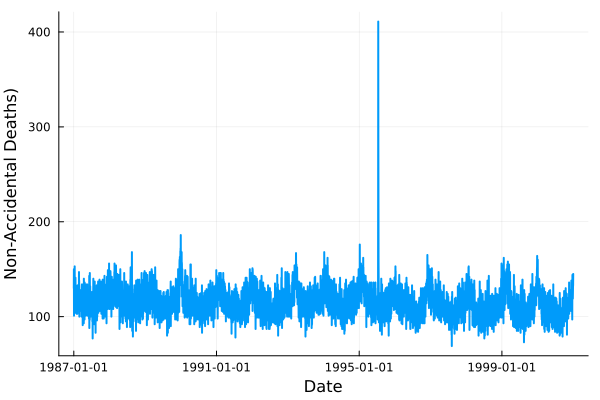

In [7]:
chicago_dat = CSV.read("data/chicago.csv", DataFrame; delim=',', header=true, missingstring="NA")
day_zero = Date("1993-12-31")
chicago_dat.Date = day_zero .+ Day.(chicago_dat.time .+ 0.5)

plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths)", legend=false)

#### Problem 2.1

Load and plot the deaths data. Linearly regress the number of deaths
against time and report the coefficient for the fitted model. Add the
regression line to your plot. What does this regression tell you?

In [8]:
model1 = lm(@formula(death ~ time), chicago_dat)

coef(model1)

2-element Vector{Float64}:
 115.41885021509579
  -0.0015206999441846655

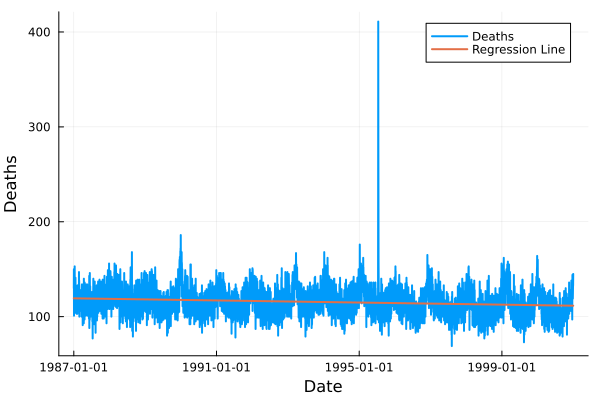

In [21]:
#plot code

plot(chicago_dat.Date, chicago_dat.death, lw = 2, label = "Deaths")

plot!(chicago_dat.Date, predict(model1), xlabel = "Date", ylabel = "Deaths", lw = 2, label = "Regression Line")

Problem 2.1

This regression tells me that the number of non-accidental deaths over time seems relatively unchanged.  The calculated coefficient (beta) of -.0015 is near 0, indicating a pretty non-impactful relationship.

#### Problem 2.2

Now linearly regress the deaths data against temperature. Once again,
report the coefficients, and add the regression line to your plot. What
does this regression tell you about the influence of temperature?

In [10]:
model2 = lm(@formula(death ~ tmpd), chicago_dat)

coef(model2)

2-element Vector{Float64}:
 129.9570512147682
  -0.2896442961500986

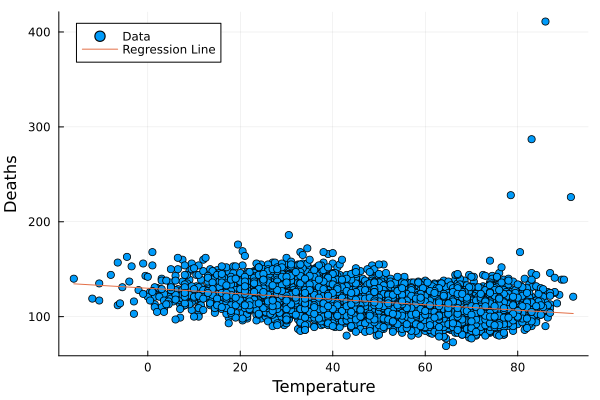

In [20]:
#plot code

scatter(chicago_dat.tmpd, chicago_dat.death, label = "Data")

plot!(chicago_dat.tmpd, predict(model2), xlabel = "Temperature", ylabel = "Deaths", label = "Regression Line")


Problem 2.2

The calculated coefficient of ~ -0.29 tells me that temperature has an inverse relationship with deaths.  This regression tells me that a one degree increase in temperature is associated with a ~0.29 fewer deaths.

#### Problem 2.3

Expand your previous model by regressing deaths against temperature and
PM2.5 density. Report the coefficients and add this regression line to
your plot.

In [12]:
data3 = dropmissing(chicago_dat, [:death, :tmpd, :pm25median])
model3 = lm(@formula(death ~ tmpd + pm25median), data3)

coef(model3)

3-element Vector{Float64}:
 129.29393325279517
  -0.37111817572293887
   0.21532754484260638

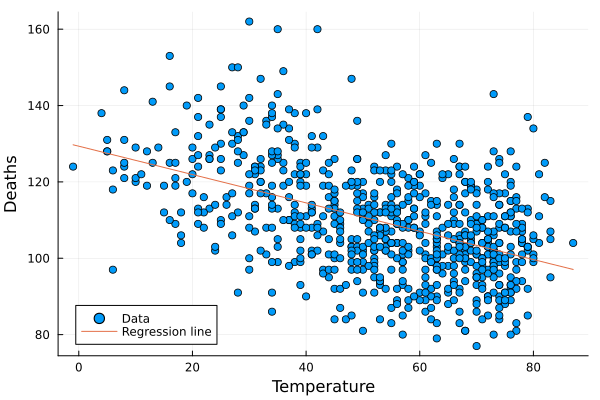

In [ ]:
scatter(data3.tmpd, data3.death, xlabel = "Temperature",
    ylabel = "Deaths", label="Data")

#in order to plot this, keep pm25 static at an average level
#so the relationship between temperature and deaths can be plotted

pm25_mean = mean(data3.pm25median)

x = data3.tmpd
#allows y to be predicted based on changing temperatures and a fixed pm25 
#so it can be graphed
y = predict(model3, (tmpd = data3.tmpd, pm25median = fill(pm25_mean, nrow(data3))))

plot!(x, y, seriestype = :line,label = "Regression line")



Problem 2.3

The coefficients are -0.371 for temperature and 0.215 for pm2.5.  This implies that a 1 degree F increase in temperature is associated with 0.371 fewer deaths (if pm2.5 is held constant) and that a 1 unit increase in PM2.5 is associated with 0.215 additional deaths (if temperature is held constant).

#### Problem 2.4

Conduct a 5-fold cross-validation for the temperature only and
temperature and PM2.5 models, using both the mean-squared-error and
log-probability metrics. Are there any structures in the dataset that
you need to account for when developing your cross-validation folds?
Which model performs the best? What can you conclude from this analysis?

In [ ]:
#reestablish the datasets

data_2 = dropmissing(chicago_dat, [:death, :tmpd, :pm25median])

#5 fold CV for tmpd first

n_2 = nrow(data_2)
k_2 = 5

#make it so that there are no rounding issuues or weird decimal instances

fold_edges_2 = round.(Int, range(1, n_2 + 1, length = k_2 + 1))

mse_tmpd_storage = Float64[]
logloss_tmpd_storage = Float64[]
mse_tmpd_pm_storage = Float64[]
logloss_tmpd_pm_storage = Float64[]

#for loop similar to 1.3

for i in 1:k_2

    test_index_2 = fold_edges_2[i]:(fold_edges_2[i+1] - 1)
    #indentifies whether it's in or out of the test index
    train_index_2 = setdiff(1:n_2, test_index_2)

    train_2 = data_2[train_index_2, :]
    test_2 = data_2[test_index_2, :]

    #fit model to training data
    model_tmpd = lm(@formula(death ~ tmpd), train_2)
    model_tmpd_pm = lm(@formula(death ~ tmpd + pm25median), train_2)

    #establish y's
    y_test_2 = test_2.death
    y_hat_tmpd = predict(model_tmpd, test_2)
    y_hat_tmpd_pm = predict(model_tmpd_pm, test_2)

    #MSE calculations
    mse_tmpd = mean((y_test_2 .- y_hat_tmpd).^2)
    mse_tmpd_pm = mean((y_test_2 .- y_hat_tmpd_pm).^2)
    push!(mse_tmpd_storage, mse_tmpd)
    push!(mse_tmpd_pm_storage, mse_tmpd_pm)

    #calculate sigma from residuals
    sigma_tmpd = sqrt(mean(residuals(model_tmpd).^2))
    sigma_tmpd_pm = sqrt(mean(residuals(model_tmpd_pm).^2))

    #store logloss
    ll_tmpd = -mean(logpdf.(Normal.(y_hat_tmpd, sigma_tmpd), y_test_2))
    ll_tmpd_pm = -mean(logpdf.(Normal.(y_hat_tmpd_pm, sigma_tmpd_pm), y_test_2))

    push!(logloss_tmpd_storage, ll_tmpd)
    push!(logloss_tmpd_pm_storage, ll_tmpd_pm)
end

println("Temperature-only CV MSE = ", mean(mse_tmpd_storage))
println("Temperature-only CV Log-loss = ", mean(logloss_tmpd_storage))
println("Temperature and PM2.5 CV MSE = ", mean(mse_tmpd_pm_storage))
println("Temperature and PM2.5 CV Log-loss = ", mean(logloss_tmpd_pm_storage))

Temperature-only CV MSE = 157.0693454313179
Temperature-only CV Log-loss = 3.9496816725958355
Temperature and PM2.5 CV MSE = 153.6256378592379
Temperature and PM2.5 CV Log-loss = 3.938652964876848


Problem 2.4


There is absolutely a structure in the dataset that had to be accounted for, and that was the time-series component of the data.  As there was a temporal component, that meant that the folds were conducted in a way that was sequential.  Doing this ensured that there wasn't a random instance of a cluster of close dates in the folds and handled temporal dependence.  Utilizing a K future out CV would likely make more sense here as that better handles time series data.

The model that performs the best is the model that includes both Temperature and PM2.5.  Granted, from this analysis, it is only marginal improvement, but based on the lower CV MSE and CV Log-loss values, I can conlude that PM2.5 does offer additional slight explanation and prediction that is separate from just temperature.


#### Problem 2.5

Compute the AICs for the three fitted models and compare them. What do they tell you about the relative evidence for the influence of temperature and PM2.5 density on deaths? How do your conclusions based on AIC compare to those you might draw from your regression coefficients, plots, and cross-validation?


In [ ]:
#set dataset to keep AIC comparisons consistent

dataAIC = dropmissing(chicago_dat, [:death, :time, :tmpd, :pm25median])

#fit models

model1 = lm(@formula(death ~ time), dataAIC)
model2 = lm(@formula(death ~ tmpd), dataAIC)
model3 = lm(@formula(death ~ tmpd + pm25median), dataAIC)

#calculate AICs

println("AIC (time only) = ", aic(model1))
println("AIC (temperature only) = ", aic(model2))
println("AIC (temperature + PM2.5) = ", aic(model3))

AIC (time only) = 5918.129872072014
AIC (temperature only) = 5729.004547432589
AIC (temperature + PM2.5) = 5714.315656401006


Problem 2.5

The AICs tell me that there is relative evidence of the influence of temperature and PM2.5 density on deaths.  

The worst performing model is just time alone.  This is then improved by adding in the influence of temperature, and then further improved by adding temperature and PM2.5 together.  We can conclude that the strongest support is for the model that includes temperature and PM2.5 as it has the lowest AIC.  This is consistent with the cross-validation results as those also indicated improved model performance when accounting for PM2.5.  This is also consistent with the regression coefficient results and the plots that were graphed.


# References

OpenAI. (2024). ChatGPT (Sept 25 GPT-5 version) [Large language model].
https://chat.openai.com:  I utilized ChatGPT to help specifically with code development and some julia-specific syntax guidance.  The main ideas behind the code formulation and the actual analysis was performed by me.